In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer

In [2]:
df = pd.read_csv("wine_data.csv")

In [18]:
df.columns = [f'f{i}' for i in range(1, len(df.columns) + 1)]
df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [19]:
df.isnull().sum()

f1     0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
f10    0
f11    0
f12    0
f13    0
f14    0
dtype: int64

In [9]:
def detect_outliers(data):
    outliers = {}
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1      
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR       
        outliers[col] = data[(data[col] < lower) | (data[col] > upper)][col]   
    return outliers
outliers = detect_outliers(df)
print("\nOutliers detected:")
for col, vals in outliers.items():
    print(f"{col}: {len(vals)} outliers")


Outliers detected:
f1: 0 outliers
f2: 0 outliers
f3: 3 outliers
f4: 3 outliers
f5: 4 outliers
f6: 4 outliers
f7: 0 outliers
f8: 0 outliers
f9: 0 outliers
f10: 2 outliers
f11: 3 outliers
f12: 1 outliers
f13: 0 outliers
f14: 0 outliers


BEFORE SCALING

Mean:
 f1       1.943503
f2      12.993672
f3       2.339887
f4       2.366158
f5      19.516949
f6      99.587571
f7       2.292260
f8       2.023446
f9       0.362316
f10      1.586949
f11      5.054802
f12      0.956983
f13      2.604294
f14    745.096045
dtype: float64

Standard Deviation:
 f1       0.773991
f2       0.808808
f3       1.119314
f4       0.275080
f5       3.336071
f6      14.174018
f7       0.626465
f8       0.998658
f9       0.124653
f10      0.571545
f11      2.324446
f12      0.229135
f13      0.705103
f14    314.884046
dtype: float64


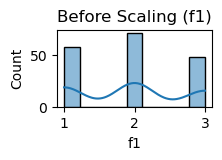

In [34]:
print("BEFORE SCALING")
print("\nMean:\n", df.mean())
print("\nStandard Deviation:\n", df.std())
plt.figure(figsize=(2,1))
sns.histplot(df['f1'], kde=True)
plt.title("Before Scaling (f1)")
plt.show()

In [11]:
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df), columns=df.columns)

In [12]:
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns=df.columns)

In [13]:
robust_scaler = RobustScaler()
df_robust = pd.DataFrame(robust_scaler.fit_transform(df), columns=df.columns)

In [14]:
maxabs_scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df), columns=df.columns)

In [15]:
df_mean_norm = (df - df.mean()) / (df.max() - df.min())

In [28]:
print("AFTER STANDARDIZATION")
print("\nMean:\n", df_standard.mean())
print("\nStandard Deviation:\n", df_standard.std())

AFTER STANDARDIZATION

Mean:
 f1    -8.028731e-17
f2    -5.218675e-16
f3     2.810056e-16
f4    -3.813647e-16
f5    -2.408619e-16
f6    -8.028731e-17
f7    -2.810056e-16
f8     1.605746e-16
f9    -6.021549e-16
f10   -4.014366e-17
f11    1.806465e-16
f12    6.021549e-16
f13    7.225858e-16
f14    1.605746e-16
dtype: float64

Standard Deviation:
 f1     1.002837
f2     1.002837
f3     1.002837
f4     1.002837
f5     1.002837
f6     1.002837
f7     1.002837
f8     1.002837
f9     1.002837
f10    1.002837
f11    1.002837
f12    1.002837
f13    1.002837
f14    1.002837
dtype: float64


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Original')

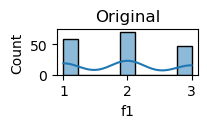

In [38]:
plt.figure(figsize=(4,2))
plt.subplot(3,2,1)
sns.histplot(df['f1'], kde=True)
plt.title("Original")

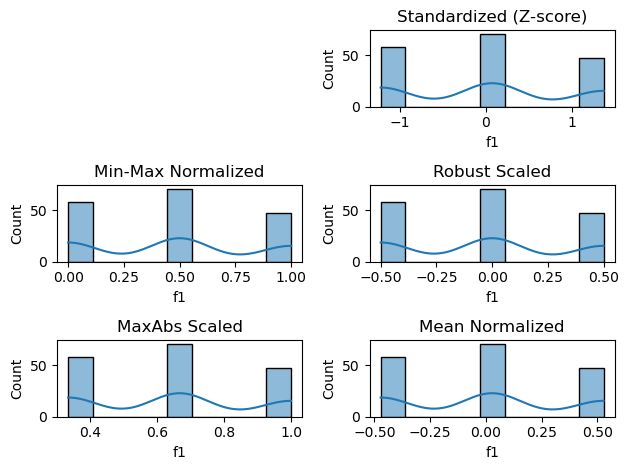

In [39]:
plt.subplot(3,2,2)
sns.histplot(df_standard[col], kde=True)
plt.title("Standardized (Z-score)")

plt.subplot(3,2,3)
sns.histplot(df_minmax[col], kde=True)
plt.title("Min-Max Normalized")

plt.subplot(3,2,4)
sns.histplot(df_robust[col], kde=True)
plt.title("Robust Scaled")

plt.subplot(3,2,5)
sns.histplot(df_maxabs[col], kde=True)
plt.title("MaxAbs Scaled")

plt.subplot(3,2,6)
sns.histplot(df_mean_norm[col], kde=True)
plt.title("Mean Normalized")

plt.tight_layout()
plt.show()